#Pertanyaan Bisnis

1. Faktor apa saja yang paling memengaruhi risiko gagal bayar pengguna berdasarkan data penggunaan kartu kredit dan riwayat pembayaran dalam beberapa bulan terakhir?
2. Bagaimana hubungan antara rasio utang dan keterlambatan pembayaran terhadap risiko gagal bayar berdasarkan histori data transaksi?
3. Model machine learning apa yang memiliki kemampuan terbaik dalam mendeteksi risiko gagal bayar pengguna berdasarkan metrik evaluasi recall, F1-score, dan ROC-AUC?

#Instalasi dan Import

In [ ]:
pip install kagglehub

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

#Data Wrangling

##Gathering Data

In [ ]:
# Download latest version
path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")

print("Path to dataset files:", path)

100%|██████████| 0.98M/0.98M [00:00<00:00, 89.2MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/uciml/default-of-credit-card-clients-dataset/versions/1


In [ ]:
df = pd.read_csv(os.path.join(path, "UCI_Credit_Card.csv"))

In [ ]:
df.head(10)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
5,6,50000.0,1,1,2,37,0,0,0,0,...,19394.0,19619.0,20024.0,2500.0,1815.0,657.0,1000.0,1000.0,800.0,0
6,7,500000.0,1,1,2,29,0,0,0,0,...,542653.0,483003.0,473944.0,55000.0,40000.0,38000.0,20239.0,13750.0,13770.0,0
7,8,100000.0,2,2,2,23,0,-1,-1,0,...,221.0,-159.0,567.0,380.0,601.0,0.0,581.0,1687.0,1542.0,0
8,9,140000.0,2,3,1,28,0,0,2,0,...,12211.0,11793.0,3719.0,3329.0,0.0,432.0,1000.0,1000.0,1000.0,0
9,10,20000.0,1,3,2,35,-2,-2,-2,-2,...,0.0,13007.0,13912.0,0.0,0.0,0.0,13007.0,1122.0,0.0,0


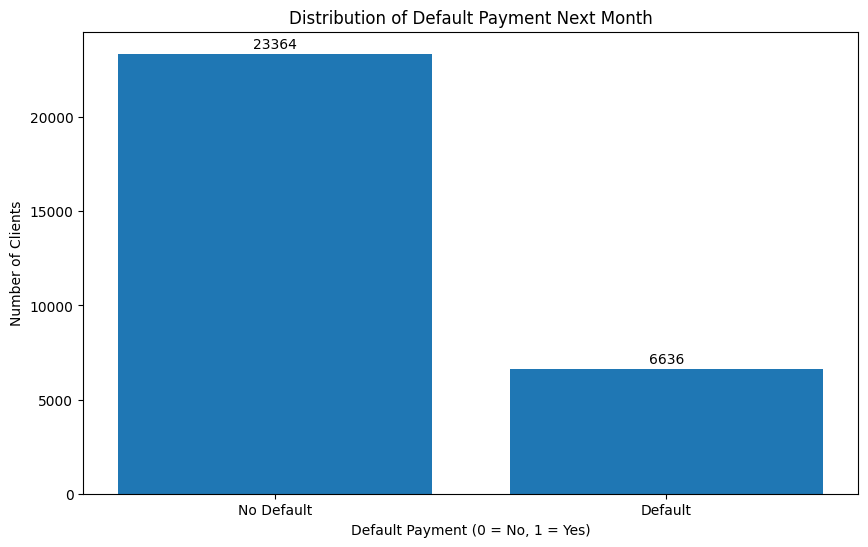

In [ ]:
plt.figure(figsize=(10, 6))

default_counts = df['default.payment.next.month'].value_counts()
bars = plt.bar(default_counts.index, default_counts.values)
plt.title('Distribution of Default Payment Next Month')
plt.xlabel('Default Payment (0 = No, 1 = Yes)')
plt.ylabel('Number of Clients')
plt.xticks([0, 1], ['No Default', 'Default'])

# Add numerical labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 100, round(yval, 2), ha='center', va='bottom') # +100 to offset text slightly above the bar

plt.show()

Penjelasan:
Terdapat ketidakseimbangan data dimana data pada kategori no default lebih banyak dibandingkan dengan default dengan jumlah data no default adalah 23364 dan default 6636.

##Assessing Data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [ ]:
print("Jumlah data kosong:\n")
df.isna().sum()

Jumlah data kosong:



,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


In [ ]:
print("Jumlah data duplikat: ", df.duplicated().sum())

Jumlah data duplikat:  0


In [ ]:
df['MARRIAGE'].value_counts()

,count
MARRIAGE,
2,15964
1,13659
3,323
0,54


MARRIAGE: Marital status (1 = married, 2 = single, 3 = others) <br>
Di kolom marriage ada kategori 0 yang dimana tidak ada di dalam deskripsi dataset asli


In [ ]:
df['EDUCATION'].value_counts()

,count
EDUCATION,
2,14030
1,10585
3,4917
5,280
4,123
6,51
0,14


EDUCATION: (1 = graduate school, 2 = university, 3 = high school, 4 = others, 5 = unknown, 6 = unknown) <br>
Terdapat kategori 0 yang tidak ada pada deskripsi dataset, selain itu kategori 4, 5, dan 6 bisa digabung karena memiliki label yang sama

In [ ]:
df['SEX'].value_counts()

,count
SEX,
2,18112
1,11888


In [ ]:
pay_columns = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

for col in pay_columns:
    print(f"\nValue counts for {col}:")
    display(df[col].value_counts().sort_index())


Value counts for PAY_0:


,count
PAY_0,
-2,2759
-1,5686
0,14737
1,3688
2,2667
3,322
4,76
5,26
6,11



Value counts for PAY_2:


,count
PAY_2,
-2,3782
-1,6050
0,15730
1,28
2,3927
3,326
4,99
5,25
6,12



Value counts for PAY_3:


...

,count
PAY_4,
-2,4348
-1,5687
0,16455
1,2
2,3159
3,180
4,69
5,35
6,5



Value counts for PAY_5:


,count
PAY_5,
-2,4546
-1,5539
0,16947
2,2626
3,178
4,84
5,17
6,4
7,58



Value counts for PAY_6:


,count
PAY_6,
-2,4895
-1,5740
0,16286
2,2766
3,184
4,49
5,13
6,19
7,46


Penjelasan: Label PAY_0 - PAY_6 (-1=pay duly, 1=payment delay for one month, 2=payment delay for two months, … 8=payment delay for eight months, 9=payment delay for nine months and above) <br>

*   Ditemukan kategori tambahan pada fitur repayment status yaitu -2 dan 0 yang tidak dijelaskan dalam dokumentasi dataset asli. Nilai tersebut tetap dipertahankan karena jumlahnya signifikan dan masih merepresentasikan kondisi pembayaran pengguna.
*  Nama kolom PAY_0 bisa diubah namanya ke PAY_1 agar penamaan fitur repayment status menjadi lebih konsisten dan terurut.



In [ ]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


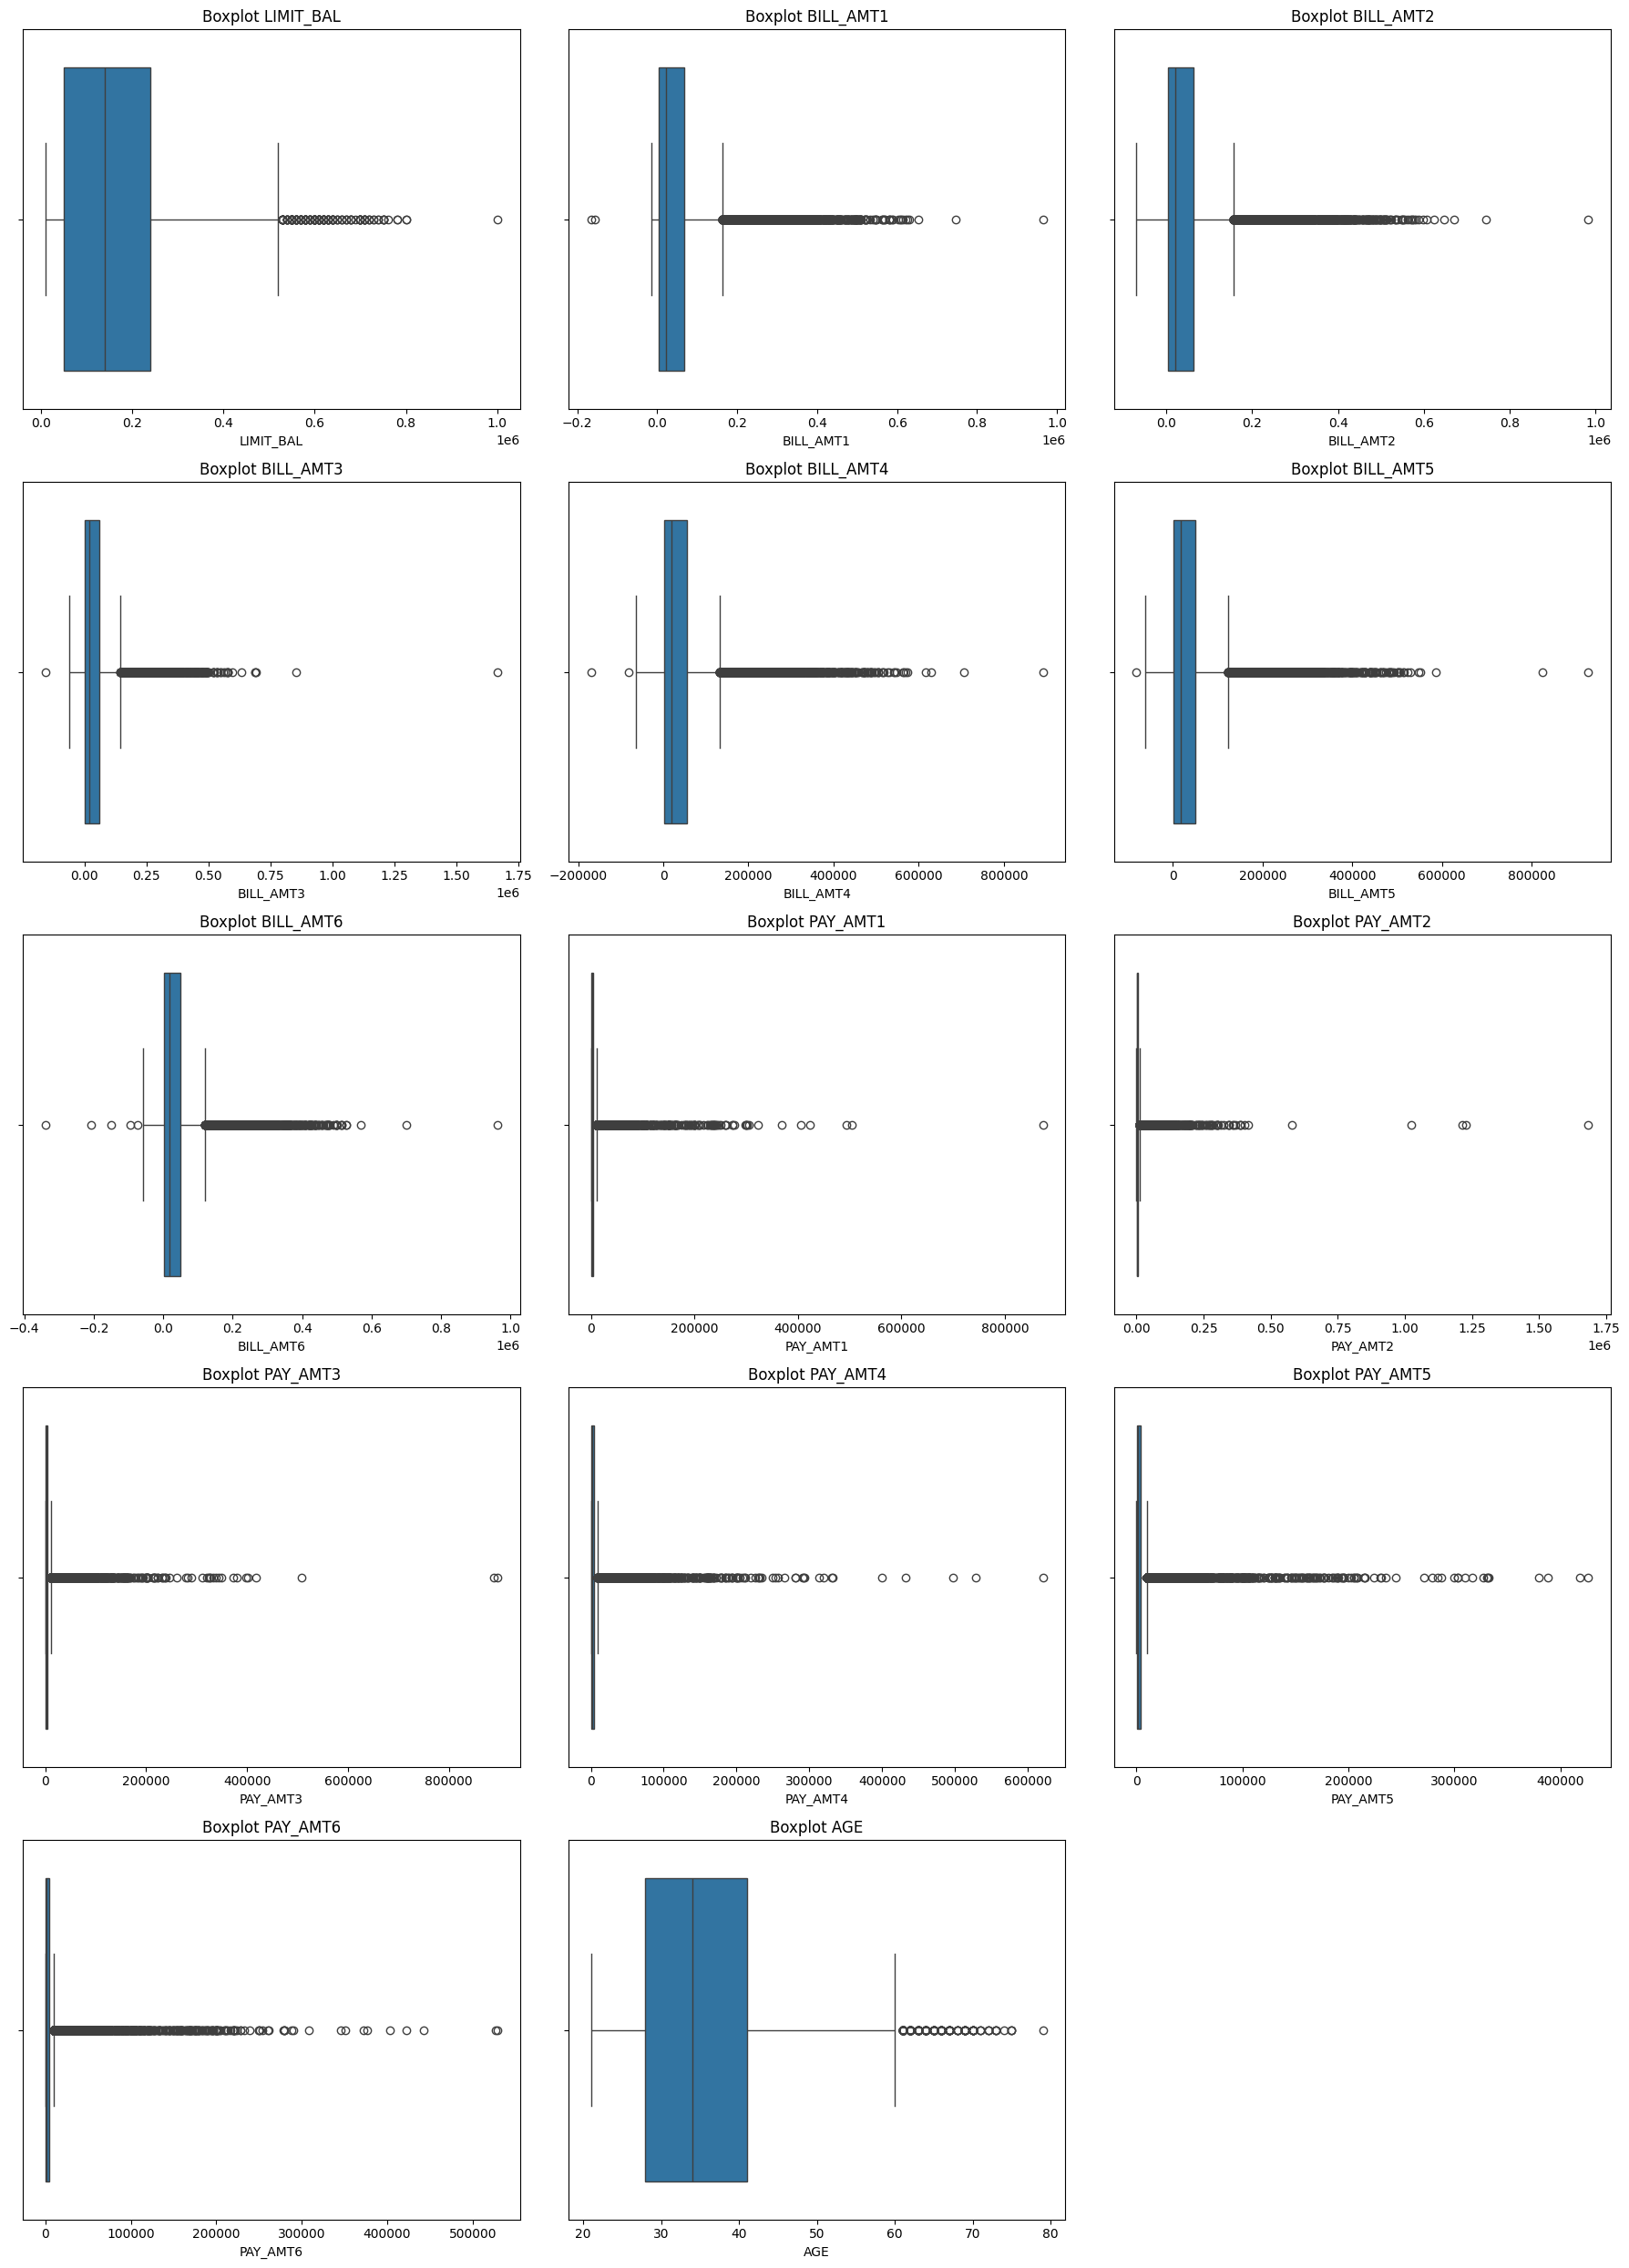

In [ ]:
#Cek Outlier
boxplot_cols = ['LIMIT_BAL', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
    'BILL_AMT4', 'BILL_AMT5','BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
    'PAY_AMT4','PAY_AMT5','PAY_AMT6','AGE']


# Tentukan ukuran grid
n_cols = 3
n_rows = (len(boxplot_cols) + n_cols - 1) // n_cols

# Buat subplot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))

# Flatten axes biar mudah looping
axes = axes.flatten()

# Plot boxplot
for i, col in enumerate(boxplot_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot {col}')

# Hapus subplot kosong jika ada
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Berdasarkan hasil visualisasi boxplot pada fitur numerik, terlihat bahwa sebagian besar fitur memiliki sejumlah nilai yang berada di luar rentang whisker boxplot yang mengindikasikan adanya potensi outlier. Jumlah outlier terlihat cukup signifikan terutama pada fitur yang berkaitan dengan nominal finansial. Adapun untuk fitur AGE dan LIMIT_BAL nilainya berada di dalam rentang whisker boxplot.

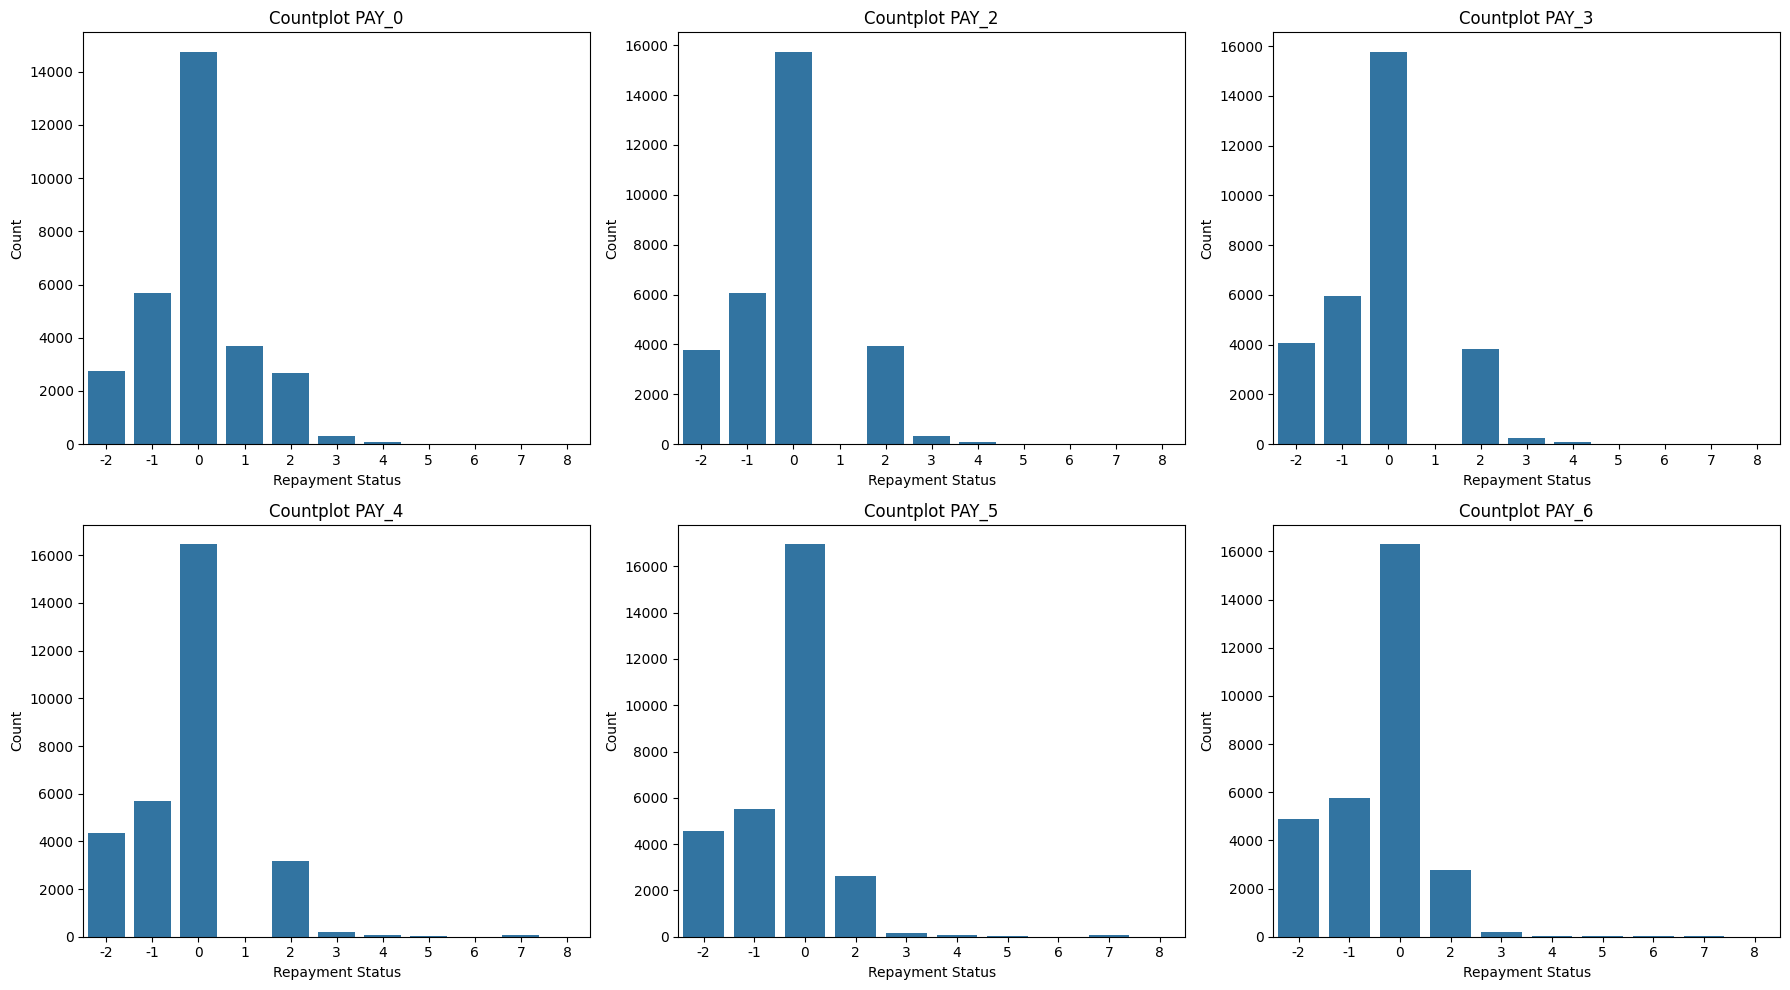

In [ ]:
# Buat layout subplot
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Flatten biar mudah diloop
axes = axes.flatten()

# Loop countplot
for i, col in enumerate(pay_columns):
    sns.countplot(
        x=df[col],
        ax=axes[i],
        order=sorted(df[col].unique())
    )

    axes[i].set_title(f'Countplot {col}')
    axes[i].set_xlabel('Repayment Status')
    axes[i].set_ylabel('Count')

# Rapihkan layout
plt.tight_layout()
plt.show()

Berdasarkan hasil visualisasi countplot pada fitur PAY_0 hingga PAY_6, ditemukan bahwa kategori 0 mendominasi hampir seluruh kolom repayment status. Selain itu, kategori -1 dan -2 juga memiliki jumlah data yang cukup besar dibandingkan kategori lainnya.

Sebaliknya, kategori keterlambatan pembayaran tinggi seperti 3 hingga 8 memiliki jumlah yang relatif sedikit. Hal ini menunjukkan bahwa sebagian besar pengguna pada dataset cenderung tidak mengalami keterlambatan pembayaran yang berat.

Selain itu, ditemukan beberapa kondisi pada data:

- Kategori 9 tidak muncul pada seluruh fitur repayment status meskipun dijelaskan pada dokumentasi dataset.
- Pada fitur PAY_5 dan PAY_6, kategori 1 tidak ditemukan sama sekali.

Temuan ini menunjukkan bahwa distribusi repayment status bersifat tidak seimbang (imbalanced), di mana mayoritas pengguna berada pada kondisi pembayaran normal atau keterlambatan rendah

##Data Cleaning

In [ ]:
#Buang kolom ID
df = df.drop('ID', axis=1)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   LIMIT_BAL                   30000 non-null  float64
 1   SEX                         30000 non-null  int64  
 2   EDUCATION                   30000 non-null  int64  
 3   MARRIAGE                    30000 non-null  int64  
 4   AGE                         30000 non-null  int64  
 5   PAY_0                       30000 non-null  int64  
 6   PAY_2                       30000 non-null  int64  
 7   PAY_3                       30000 non-null  int64  
 8   PAY_4                       30000 non-null  int64  
 9   PAY_5                       30000 non-null  int64  
 10  PAY_6                       30000 non-null  int64  
 11  BILL_AMT1                   30000 non-null  float64
 12  BILL_AMT2                   30000 non-null  float64
 13  BILL_AMT3                   300

In [ ]:
#Ubah nama kolom
df.rename(columns={
    'default.payment.next.month': 'default',
    'PAY_0': 'PAY_1'
}, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LIMIT_BAL  30000 non-null  float64
 1   SEX        30000 non-null  int64  
 2   EDUCATION  30000 non-null  int64  
 3   MARRIAGE   30000 non-null  int64  
 4   AGE        30000 non-null  int64  
 5   PAY_1      30000 non-null  int64  
 6   PAY_2      30000 non-null  int64  
 7   PAY_3      30000 non-null  int64  
 8   PAY_4      30000 non-null  int64  
 9   PAY_5      30000 non-null  int64  
 10  PAY_6      30000 non-null  int64  
 11  BILL_AMT1  30000 non-null  float64
 12  BILL_AMT2  30000 non-null  float64
 13  BILL_AMT3  30000 non-null  float64
 14  BILL_AMT4  30000 non-null  float64
 15  BILL_AMT5  30000 non-null  float64
 16  BILL_AMT6  30000 non-null  float64
 17  PAY_AMT1   30000 non-null  float64
 18  PAY_AMT2   30000 non-null  float64
 19  PAY_AMT3   30000 non-null  float64
 20  PAY_AM

Pada tahap data cleaning dilakukan perubahan nama beberapa kolom agar lebih konsisten dan mudah dipahami pada proses analisis. Kolom default.payment.next.month diubah menjadi default untuk menyederhanakan penamaan target variabel. Selain itu, kolom PAY_0 diubah menjadi PAY_1 agar urutan fitur repayment status menjadi lebih konsisten.

In [ ]:
# Penggabungan kategori pada fitur marriage & education
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)
df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)
print(df['MARRIAGE'].value_counts().sort_index())
print(df['EDUCATION'].value_counts().sort_index())
# Penggabungan kategori 4 - 9 pada fitur PAY_1 - PAY_6
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
for col in pay_columns:
    df[col] = df[col].replace([4, 5, 6, 7, 8, 9], 3)
    print(df[col].value_counts().sort_index())



MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64
PAY_1
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      463
Name: count, dtype: int64
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      483
Name: count, dtype: int64
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      390
Name: count, dtype: int64
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      349
Name: count, dtype: int64
PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      342
Name: count, dtype: int64
PAY_6
-2     4895
-1     5740
 0    16286
 2     2766
 3      313
Name: count, dtype: int64


In [ ]:
outlier_cols= ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
    'BILL_AMT4', 'BILL_AMT5','BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
    'PAY_AMT4','PAY_AMT5','PAY_AMT6']
for col in outlier_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    print(col, lower, upper)
    df[col] = np.clip(df[col], lower, upper)

BILL_AMT1 -81.0 350110.6799999999
BILL_AMT2 -200.0 337495.27999999997
BILL_AMT3 -200.0 325030.38999999897
BILL_AMT4 -212.01999999999998 304997.26999999996
BILL_AMT5 -232.01 285868.32999999996
BILL_AMT6 -331.03 279505.05999999965
PAY_AMT1 0.0 66522.17999999854
PAY_AMT2 0.0 76651.01999999999
PAY_AMT3 0.0 70000.0
PAY_AMT4 0.0 67054.43999999961
PAY_AMT5 0.0 65607.55999999991
PAY_AMT6 0.0 82619.04999999935


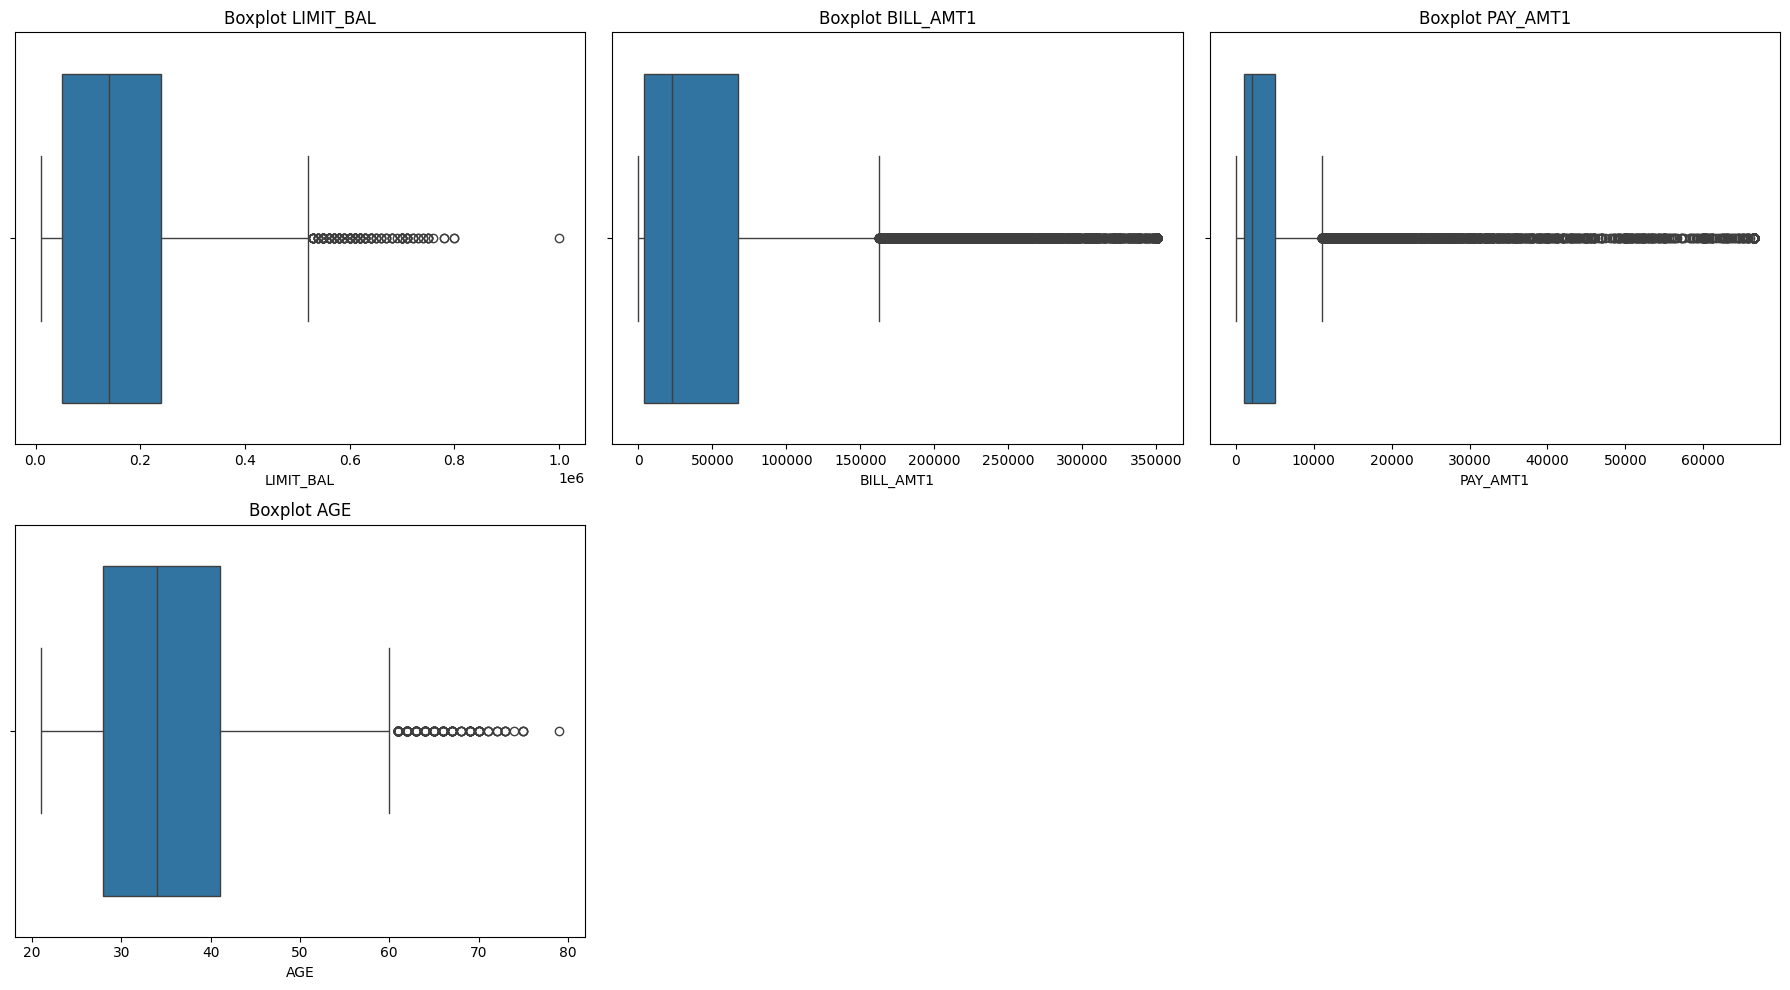

In [ ]:
boxplot_cols = ['LIMIT_BAL', 'BILL_AMT1', 'PAY_AMT1','AGE']


# Tentukan ukuran grid
n_cols = 3
n_rows = (len(boxplot_cols) + n_cols - 1) // n_cols

# Buat subplot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))

# Flatten axes biar mudah looping
axes = axes.flatten()

# Plot boxplot
for i, col in enumerate(boxplot_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot {col}')

# Hapus subplot kosong jika ada
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Outlier handling dilakukan menggunakan metode capping dengan batas persentil 1% dan 99%.
Metode ini dipilih untuk mengurangi pengaruh nilai ekstrem tanpa menghilangkan data, karena dalam konteks keuangan, nilai ekstrem masih mungkin valid. Beberapa fitur seperti LIMIT_BAL dan BILL_AMT memiliki rentang nilai yang sangat besar, sehingga perlu distabilkan agar model tidak bias terhadap nilai ekstrem.

#EDA

##RQ1: Faktor apa saja yang paling memengaruhi risiko gagal bayar pengguna berdasarkan data penggunaan kartu kredit dan riwayat pembayaran dalam beberapa bulan terakhir?

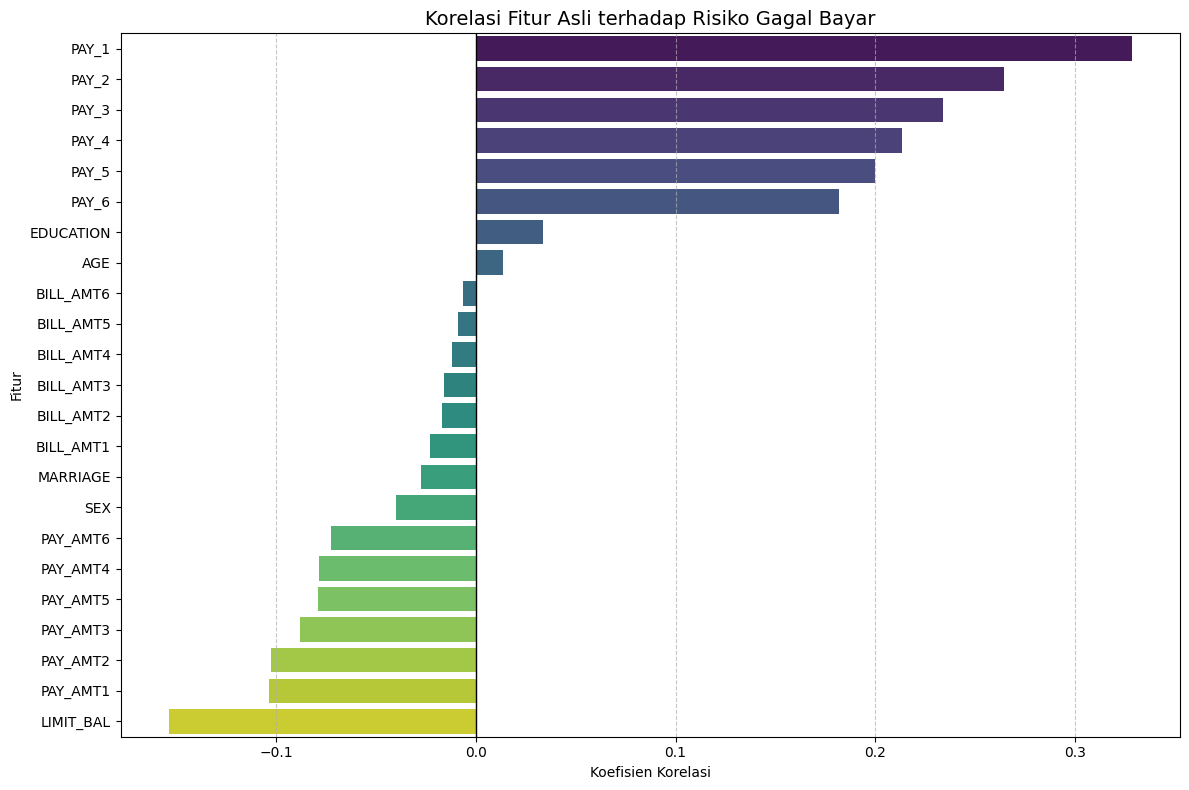

In [ ]:
corr_features = df.columns.tolist()

corr_matrix = df[corr_features].corr()

default_correlations = corr_matrix['default'].sort_values(ascending=False)

default_correlations = default_correlations.drop('default')

plt.figure(figsize=(12, 8))
sns.barplot(x=default_correlations.values, y=default_correlations.index, hue=default_correlations.index, palette='viridis', legend=False)
plt.title('Korelasi Fitur Asli terhadap Risiko Gagal Bayar',fontsize=14)
plt.xlabel('Koefisien Korelasi')
plt.ylabel('Fitur')
plt.axvline(0, color='black', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Penjelasan:
Berdasarkan grafik di atas, fitur dengan nilai correlation mendekati nol memiliki hubungan linear yang lemah dengan fitur target. Koefisien korelasi dengan nilai positif menunjukkan hubungan searah, sedangkan sebaliknya menunjukkan hubungan berlawanan arah.

In [ ]:
def vis_countplot(pay):

    # Mapping nama periode
    period_map = {
        'PAY_1': 'Current Month',
        'PAY_2': '1 Month Before',
        'PAY_3': '2 Months Before',
        'PAY_4': '3 Months Before',
        'PAY_5': '4 Months Before',
        'PAY_6': '5 Months Before'
    }

    plt.figure(figsize=(8, 6))

    sns.countplot(
        x=pay,
        hue='default',
        data=df,
        palette='viridis'
    )

    plt.title(f'Distribution of Repayment Status ({pay}) by Default Status')

    plt.xlabel(
        f'Repayment Status - {period_map.get(pay, pay)} '
        '\n(-2: Bill Not Generated, -1: Pay Duly, ... , 1+: Payment Delay 1 month, ...)'
    )

    plt.ylabel('Number of Clients')

    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

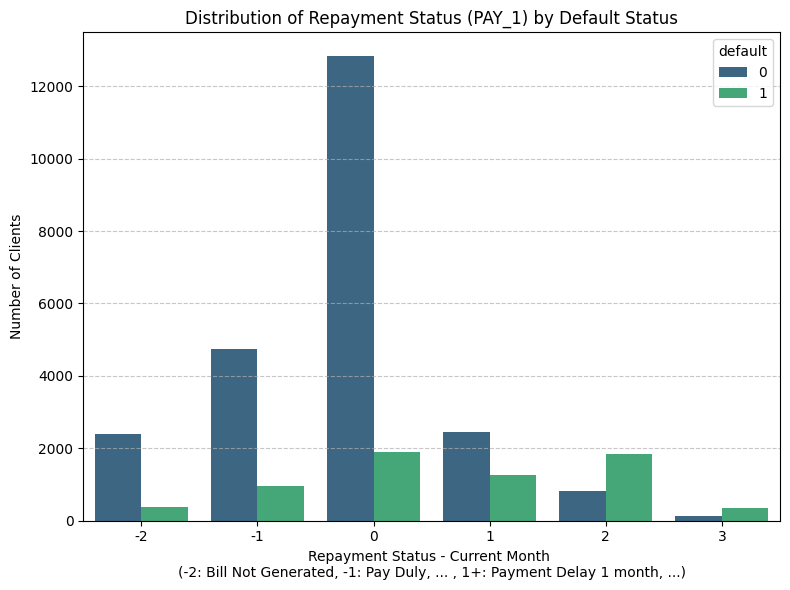

In [ ]:
vis_countplot('PAY_1')

In [ ]:
def vis_boxplot(pay):

    # Mapping periode pembayaran
    period_map = {
        'PAY_AMT1': 'Current Month Payment',
        'PAY_AMT2': '1 Month Before Payment',
        'PAY_AMT3': '2 Months Before Payment',
        'PAY_AMT4': '3 Months Before Payment',
        'PAY_AMT5': '4 Months Before Payment',
        'PAY_AMT6': '5 Months Before Payment'
    }

    plt.figure(figsize=(8, 6))

    sns.boxplot(
        x='default',
        y=pay,
        data=df,
        palette='coolwarm',
        hue='default',
        legend=False,
        showfliers=False
    )

    plt.title(
        f'Distribution of {period_map.get(pay, pay)} by Default Status'
    )

    plt.xlabel('Default Status')

    plt.ylabel(
        f'{period_map.get(pay, pay)} Amount'
    )

    plt.xticks(
        [0, 1],
        ['No Default', 'Default']
    )

    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

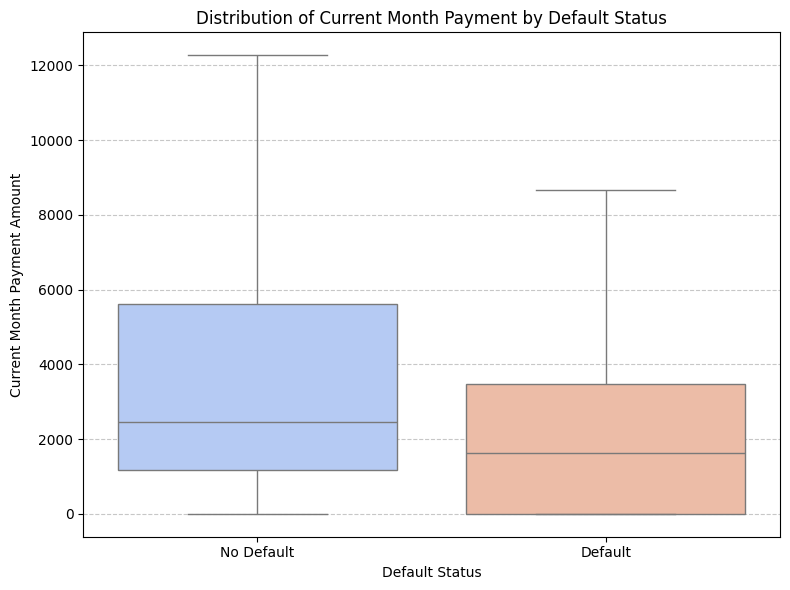

In [ ]:
vis_boxplot('PAY_AMT1')

**Penjelasan**:
Berdasarkan hasil Exploratory Data Analysis (EDA), fitur yang berkaitan dengan kondisi finansial dan riwayat pembayaran menunjukkan hubungan yang lebih kuat terhadap risiko gagal bayar dibandingkan fitur demografi seperti jenis kelamin, pendidikan, dan status pernikahan. Oleh karena itu, fitur demografi bisa dipertimbangkan untuk tidak digunakan dalam proses pemodelan. Keputusan ini diambil untuk menyederhanakan kebutuhan input pengguna pada sistem, sehingga pengguna tidak perlu memasukkan informasi yang kurang relevan terhadap prediksi. Selain itu, penghapusan fitur demografi juga bertujuan mengurangi potensi bias pada model agar prediksi lebih berfokus pada perilaku finansial dan riwayat pembayaran pengguna. Hal ini didukung oleh hasil correlation analysis yang menunjukkan bahwa fitur repayment status (PAY_1–PAY_6) memiliki korelasi lebih tinggi terhadap default dibandingkan fitur demografi. <br>
Selain itu, penggunaan riwayat pembayaran selama tiga bulan terakhir dipilih karena dinilai sudah mampu merepresentasikan perilaku pembayaran pengguna sekaligus menyederhanakan kebutuhan input sistem pada tahap implementasi

In [ ]:
df.to_csv('credit_baseline.csv', index=False)
print("Dataframe telah disimpan")

Dataframe telah disimpan


##RQ2: Bagaimana hubungan antara rasio utang dan keterlambatan pembayaran terhadap risiko gagal bayar berdasarkan histori data transaksi?

In [ ]:
##Membuat fitur baru (feature engineering)
bill_cols = ['BILL_AMT1','BILL_AMT2','BILL_AMT3']
df['total_bill'] = df[bill_cols].sum(axis=1)

pay_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3']
df['total_payment'] = df[pay_cols].sum(axis=1)

df['debt_ratio'] = np.where(
    df['LIMIT_BAL'] > 0,
    df['total_bill'] / df['LIMIT_BAL'],
    0
)

delay_cols = ['PAY_1','PAY_2','PAY_3']
df['avg_delay'] = df[delay_cols].mean(axis=1)

df['payment_ratio'] = np.where(
    df['total_bill'] > 0,
    df['total_payment'] / df['total_bill'],
    0
)

df[['total_bill', 'total_payment', 'debt_ratio', 'avg_delay', 'payment_ratio']].head()

,total_bill,total_payment,debt_ratio,avg_delay,payment_ratio
0,7704.0,689.0,0.385200,1.000000,0.089434
1,7089.0,2000.0,0.059075,0.333333,0.282127
2,56825.0,4018.0,0.631389,0.000000,0.070708
3,144514.0,5219.0,2.890280,0.000000,0.036114
4,50122.0,48681.0,1.002440,-0.666667,0.971250


In [ ]:
##Membuang kolom fitur demografi
df = df.drop(['SEX', 'EDUCATION', 'MARRIAGE', 'AGE'], axis=1)
# Membuang kolom fitur finansial 4 - 6 bulan terakhir
df = df.drop(['PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   LIMIT_BAL      30000 non-null  float64
 1   PAY_1          30000 non-null  int64  
 2   PAY_2          30000 non-null  int64  
 3   PAY_3          30000 non-null  int64  
 4   BILL_AMT1      30000 non-null  float64
 5   BILL_AMT2      30000 non-null  float64
 6   BILL_AMT3      30000 non-null  float64
 7   PAY_AMT1       30000 non-null  float64
 8   PAY_AMT2       30000 non-null  float64
 9   PAY_AMT3       30000 non-null  float64
 10  default        30000 non-null  int64  
 11  total_bill     30000 non-null  float64
 12  total_payment  30000 non-null  float64
 13  debt_ratio     30000 non-null  float64
 14  avg_delay      30000 non-null  float64
 15  payment_ratio  30000 non-null  float64
dtypes: float64(12), int64(4)
memory usage: 3.7 MB


**Penjelasan**: Setelah proses feature engineering, dilakukan pengurangan fitur dengan menghapus fitur demografi (SEX, EDUCATION, MARRIAGE, dan AGE) serta riwayat finansial bulan ke-4 hingga ke-6. Penghapusan fitur demografi dilakukan untuk mengurangi potensi bias model serta menyederhanakan kebutuhan input pengguna. Sementara itu, penggunaan data tiga bulan terakhir dipilih karena dianggap cukup merepresentasikan pola perilaku pembayaran pengguna sekaligus menjaga kompleksitas sistem tetap efisien. Hasil akhirnya diperoleh 15 fitur prediktor dan 1 target yang siap digunakan pada tahap pemodelan.

In [ ]:
# Pilih fitur finansial utama yang tersedia
financial_features = [
    'LIMIT_BAL',
    'total_bill',
    'total_payment',
    'debt_ratio',
    'payment_ratio',
    'avg_delay',
    'default'
]

financial_features = [col for col in financial_features if col in df.columns]
print("Fitur finansial yang digunakan:")
print(financial_features)

Fitur finansial yang digunakan:
['LIMIT_BAL', 'total_bill', 'total_payment', 'debt_ratio', 'payment_ratio', 'avg_delay', 'default']


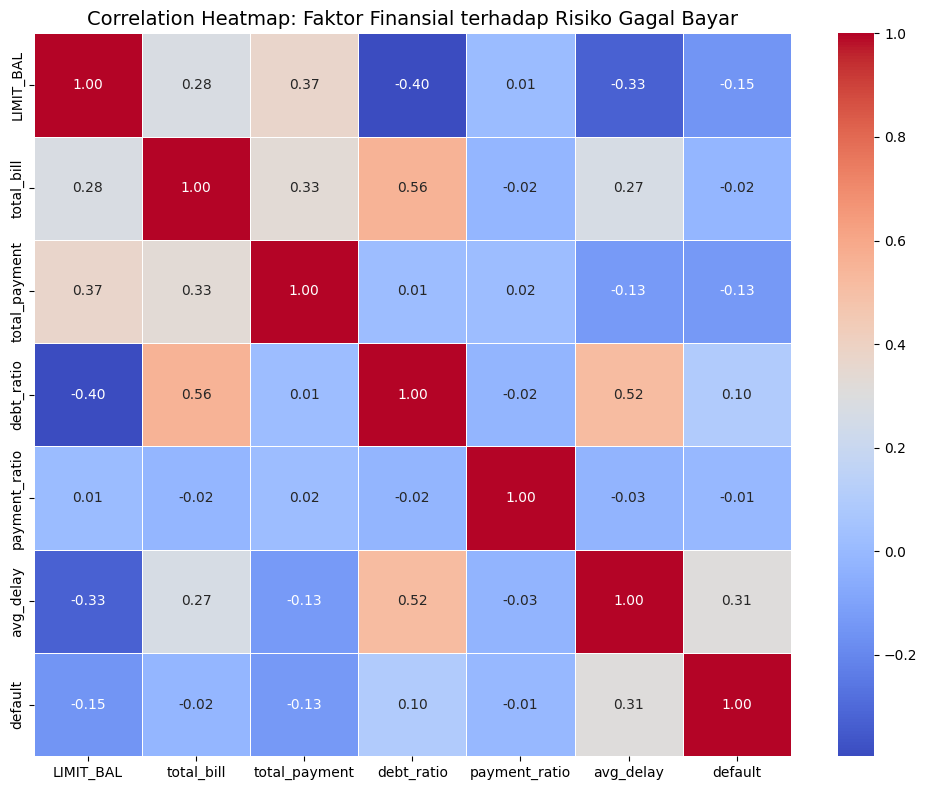

In [ ]:
# ============================================================
# 1. Correlation Heatmap
# ============================================================

corr_matrix = df[financial_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap: Faktor Finansial terhadap Risiko Gagal Bayar', fontsize=14)
plt.tight_layout()
plt.show()

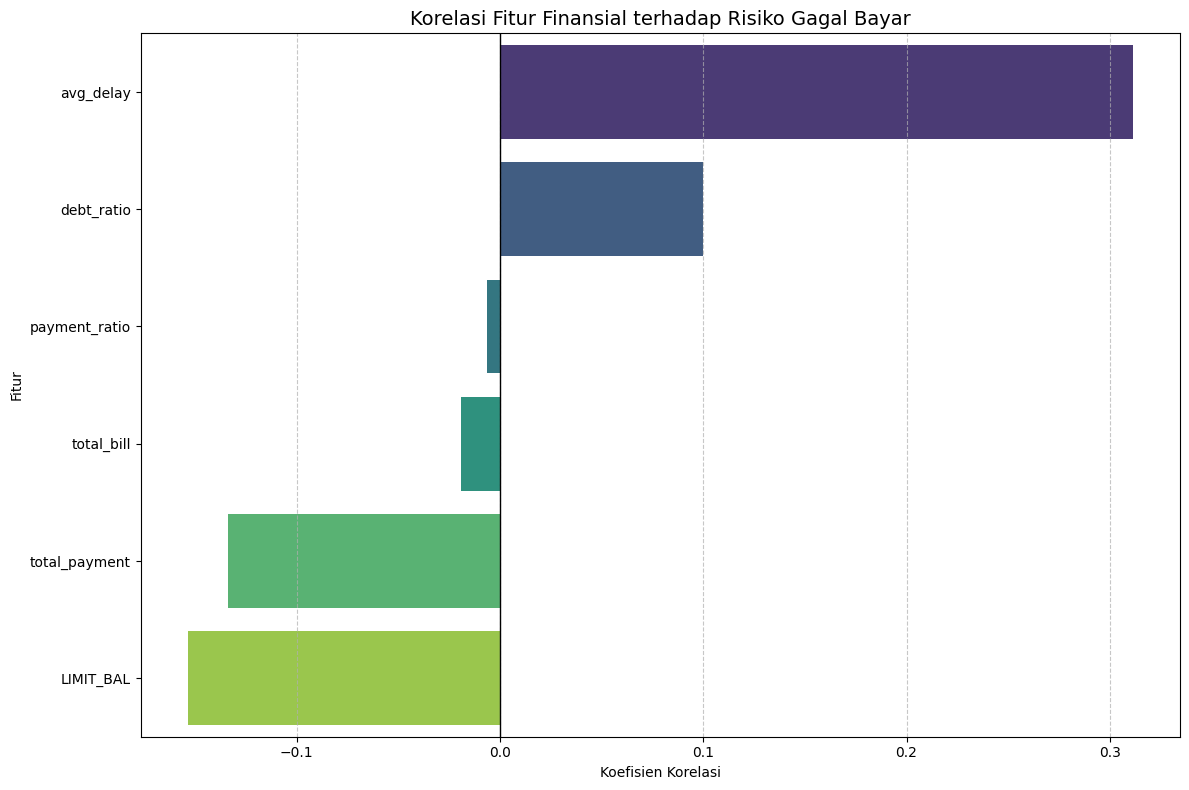

In [ ]:
corr_features = df.columns.tolist()

corr_matrix = df[financial_features].corr()

default_correlations = corr_matrix['default'].sort_values(ascending=False)

default_correlations = default_correlations.drop('default')

plt.figure(figsize=(12, 8))
sns.barplot(x=default_correlations.values, y=default_correlations.index, hue=default_correlations.index, palette='viridis', legend=False)
plt.title('Korelasi Fitur Finansial terhadap Risiko Gagal Bayar',fontsize=14)
plt.xlabel('Koefisien Korelasi')
plt.ylabel('Fitur')
plt.axvline(0, color='black', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Penjelasan**: <br>
Berdasarkan hasil correlation analysis dan visualisasi distribusi data, fitur hasil feature engineering seperti avg_delay dan debt_ratio memiliki hubungan yang lebih kuat terhadap risiko gagal bayar dibandingkan sebagian fitur finansial asli. Oleh karena itu, fitur-fitur tersebut layak digunakan pada tahap pemodelan machine learning untuk meningkatkan kemampuan model dalam mendeteksi risiko gagal bayar.

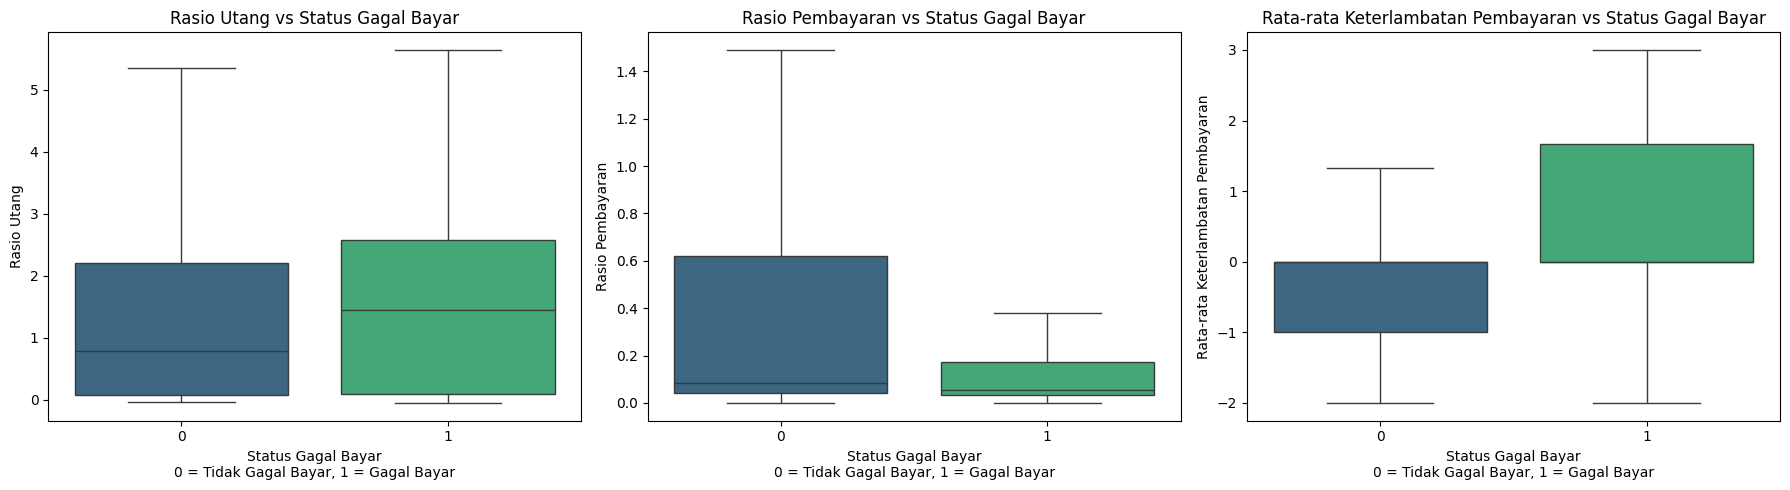

In [ ]:
boxplot_features = ['debt_ratio', 'payment_ratio', 'avg_delay']
boxplot_features = [col for col in boxplot_features if col in df.columns]

# Mapping for Indonesian titles and labels
feature_names = {
    'debt_ratio': 'Rasio Utang',
    'payment_ratio': 'Rasio Pembayaran',
    'avg_delay': 'Rata-rata Keterlambatan Pembayaran'
}

plt.figure(figsize=(18, 5))

for i, feature in enumerate(boxplot_features, 1):
    plt.subplot(1, len(boxplot_features), i)
    sns.boxplot(
        x='default',
        y=feature,
        data=df,
        palette='viridis',
        hue='default',
        legend=False,
        showfliers=False
    )
    plt.title(f'{feature_names[feature]} vs Status Gagal Bayar', fontsize=12)
    plt.xlabel('Status Gagal Bayar\n0 = Tidak Gagal Bayar, 1 = Gagal Bayar')
    plt.ylabel(feature_names[feature])

plt.tight_layout()
plt.show()

**Penjelasan**: <br>
Berdasarkan hasil boxplot, kelompok pengguna yang mengalami gagal bayar memiliki median dan distribusi debt_ratio yang lebih tinggi dibanding kelompok non-default. Sebaliknya, kelompok non-default cenderung memiliki payment_ratio yang lebih tinggi, menunjukkan kemampuan pembayaran yang lebih baik terhadap total tagihan. Selain itu, distribusi avg_delay pada kelompok default bergeser ke nilai yang lebih tinggi dibanding kelompok non-default, yang mengindikasikan bahwa keterlambatan pembayaran memiliki hubungan kuat terhadap risiko gagal bayar.

##RQ3: Model machine learning apa yang memiliki kemampuan terbaik dalam mendeteksi risiko gagal bayar pengguna berdasarkan metrik evaluasi recall, F1-score, dan ROC-AUC?

###Training

In [ ]:
# Ambil fitur numerik, exclude target
X = df.drop(columns=['default'], axis=1)
y = df['default']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah data training:", len(X_train))
print("Jumlah data testing:", len(X_test))


Jumlah data training: 24000
Jumlah data testing: 6000


In [ ]:
#Scaling fitur numerik
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Shape X_train:", X_train_scaled.shape)
print("Shape X_test:", X_test_scaled.shape)
print("Shape y_train:", y_train.shape)
print("Shape y_test:", y_test.shape)

Shape X_train: (24000, 15)
Shape X_test: (6000, 15)
Shape y_train: (24000,)
Shape y_test: (6000,)


####Logistic Regression

In [ ]:
# Train model
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

# Prediksi
y_pred = model.predict(X_test_scaled)

# Evaluasi
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# =============
# ROC-AUC
# =============

y_prob = model.predict_proba(X_test_scaled)[:,1]
roc_auc = roc_auc_score(y_test, y_prob)

print("\nROC-AUC Score:", roc_auc)

Accuracy: 0.681

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.70      0.77      4673
           1       0.37      0.61      0.46      1327

    accuracy                           0.68      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.75      0.68      0.70      6000


Confusion Matrix:
 [[3272 1401]
 [ 513  814]]

ROC-AUC Score: 0.7097873093212447


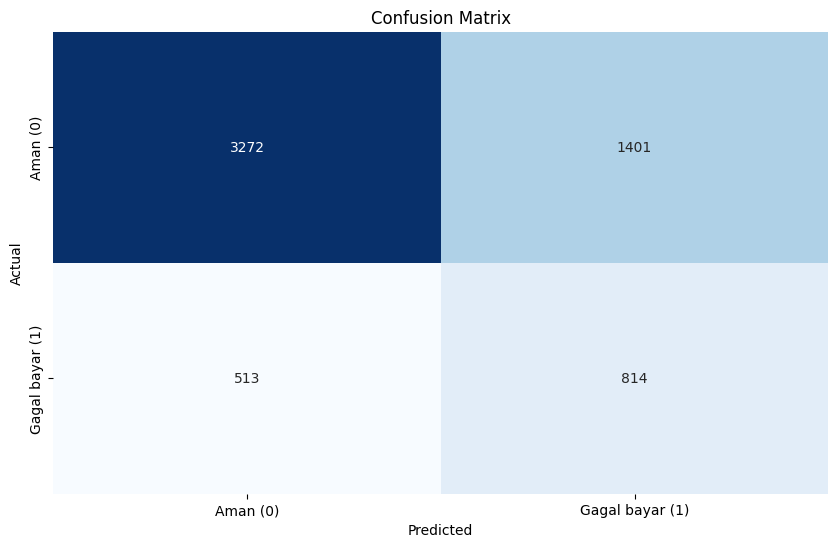

In [ ]:
plt.figure(figsize=(10, 6))

labels = ['Aman (0)', 'Gagal bayar (1)']

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=labels,
    yticklabels=labels
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
print(confusion_matrix(y_test, y_pred))

[[3272 1401]
 [ 513  814]]


####Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [ ]:
y_pred = rf.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

y_prob_rf = rf.predict_proba(X_test_scaled)[:,1]
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("\nROC-AUC Score for Random Forest:", roc_auc_rf)

Accuracy: 0.7755

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.84      0.85      4673
           1       0.49      0.56      0.52      1327

    accuracy                           0.78      6000
   macro avg       0.68      0.70      0.69      6000
weighted avg       0.79      0.78      0.78      6000


ROC-AUC Score for Random Forest: 0.7704007904441023


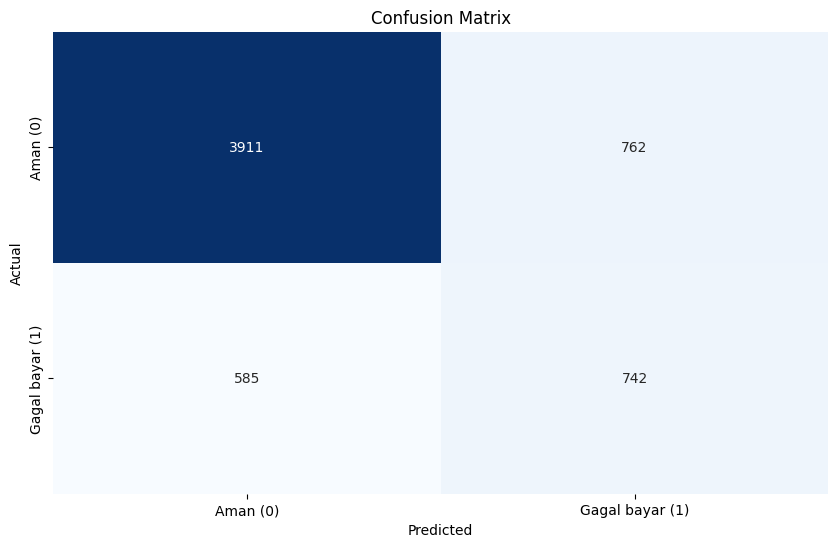

In [ ]:
plt.figure(figsize=(10, 6))

labels = ['Aman (0)', 'Gagal bayar (1)']

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=labels,
    yticklabels=labels
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
print(confusion_matrix(y_test, y_pred))

[[3911  762]
 [ 585  742]]


Berdasarkan hasil evaluasi model, Logistic Regression memiliki recall lebih tinggi pada kelas gagal bayar (0.64), sehingga lebih baik dalam mendeteksi pengguna berisiko gagal bayar. Namun, Random Forest menunjukkan performa keseluruhan yang lebih baik dengan accuracy, F1-score, precision, dan ROC-AUC yang lebih tinggi. Oleh karena itu, pemilihan model dapat disesuaikan dengan kebutuhan bisnis. Jika prioritas utama adalah meminimalkan risiko gagal mendeteksi pengguna gagal bayar, maka Logistic Regression lebih sesuai. Namun jika menginginkan performa model yang lebih seimbang dan stabil secara keseluruhan, maka Random Forest menjadi pilihan yang lebih baik.

##EDA RQ3

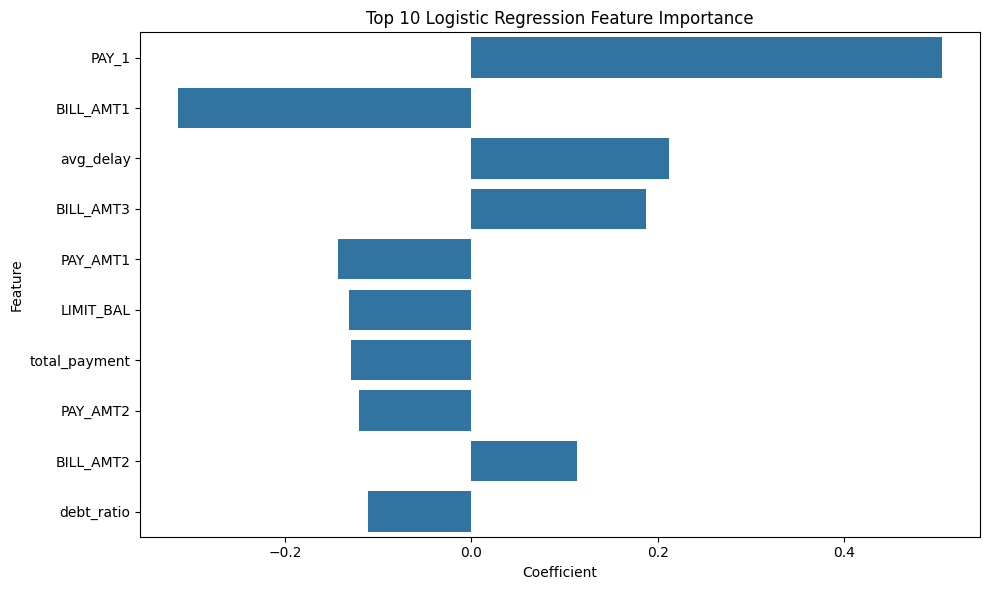

In [ ]:
lr_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

# Gunakan absolut agar urutan berdasarkan besar pengaruh
lr_importance['Abs_Coefficient'] = abs(lr_importance['Coefficient'])

lr_importance = lr_importance.sort_values(
    by='Abs_Coefficient',
    ascending=False
)

top_lr = lr_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_lr,
    x='Coefficient',
    y='Feature'
)

plt.title('Top 10 Logistic Regression Feature Importance')
plt.xlabel('Coefficient')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

In [ ]:
print('10 Fitur Terpenting untuk Logistic Regression:')
for index, row in top_lr.iterrows():
    print(f"- {row['Feature']}: {row['Abs_Coefficient']:.4f}")


10 Fitur Terpenting untuk Logistic Regression:
- PAY_1: 0.5052
- BILL_AMT1: 0.3147
- avg_delay: 0.2117
- BILL_AMT3: 0.1876
- PAY_AMT1: 0.1431
- LIMIT_BAL: 0.1315
- total_payment: 0.1294
- PAY_AMT2: 0.1206
- BILL_AMT2: 0.1134
- debt_ratio: 0.1112


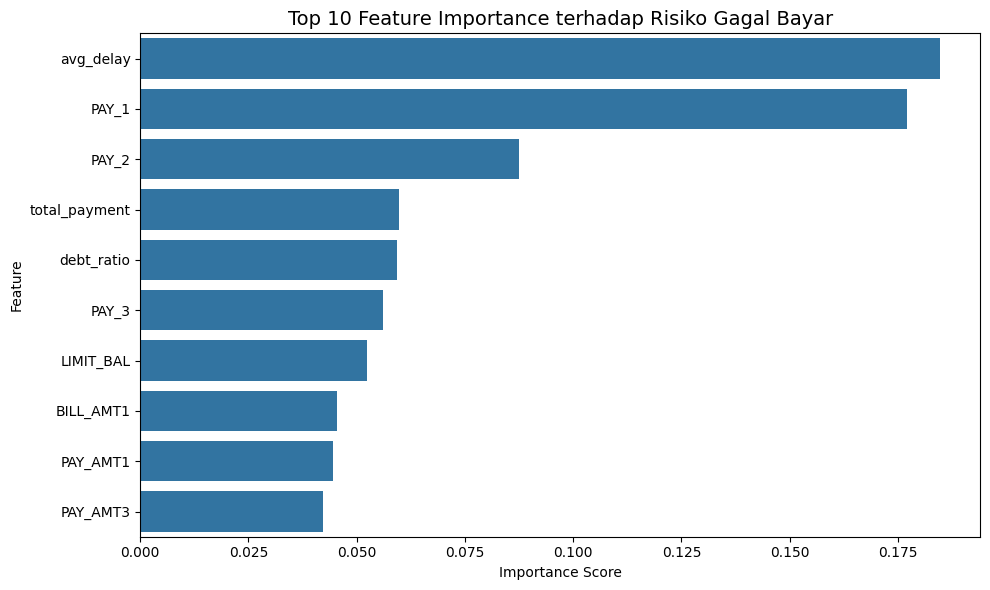

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)


plt.title('Top 10 Feature Importance terhadap Risiko Gagal Bayar', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
print('10 Fitur Terpenting untuk Random Forest:')
for index, row in top_features.iterrows():
    print(f"- {row['Feature']}: {row['Importance']:.4f}")


10 Fitur Terpenting untuk Random Forest:
- avg_delay: 0.1847
- PAY_1: 0.1772
- PAY_2: 0.0875
- total_payment: 0.0597
- debt_ratio: 0.0594
- PAY_3: 0.0562
- LIMIT_BAL: 0.0524
- BILL_AMT1: 0.0454
- PAY_AMT1: 0.0444
- PAY_AMT3: 0.0423


In [ ]:
df.to_csv('credit_final.csv', index=False)
print("Dataframe telah disimpan")

Dataframe telah disimpan


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   LIMIT_BAL      30000 non-null  float64
 1   PAY_1          30000 non-null  int64  
 2   PAY_2          30000 non-null  int64  
 3   PAY_3          30000 non-null  int64  
 4   BILL_AMT1      30000 non-null  float64
 5   BILL_AMT2      30000 non-null  float64
 6   BILL_AMT3      30000 non-null  float64
 7   PAY_AMT1       30000 non-null  float64
 8   PAY_AMT2       30000 non-null  float64
 9   PAY_AMT3       30000 non-null  float64
 10  default        30000 non-null  int64  
 11  total_bill     30000 non-null  float64
 12  total_payment  30000 non-null  float64
 13  debt_ratio     30000 non-null  float64
 14  avg_delay      30000 non-null  float64
 15  payment_ratio  30000 non-null  float64
dtypes: float64(12), int64(4)
memory usage: 3.7 MB


Dalam project ini, dilakukan perbandingan antara Logistic Regression dan Random Forest untuk mengevaluasi performa model dalam memprediksi gagal bayar. Random Forest yang telah melalui proses hyperparameter tuning menunjukkan performa yang lebih tinggi dari segi akurasi dan ROC-AUC yang mengindikasikan kemampuan model dalam menangkap pola data yang lebih kompleks.

Namun, dalam konteks prediksi gagal bayar, metrik recall menjadi fokus utama karena berkaitan langsung dengan kemampuan model dalam mendeteksi nasabah yang berpotensi gagal bayar. Hasil evaluasi menunjukkan bahwa Logistic Regression memiliki nilai recall yang lebih tinggi dibandingkan Random Forest, sehingga lebih efektif dalam mengidentifikasi kasus berisiko.

Selain itu, dataset yang digunakan memiliki ketidakseimbangan kelas (class imbalance), di mana jumlah nasabah yang tidak gagal bayar lebih dominan. Kondisi ini menyebabkan metrik seperti akurasi dan ROC-AUC kurang representatif jika digunakan sebagai satu-satunya dasar pemilihan model. Oleh karena itu, pemilihan model lebih difokuskan pada kemampuan dalam mendeteksi kelas minoritas.

Dalam konteks sistem keuangan, kesalahan dalam mendeteksi nasabah berisiko (false negative) memiliki dampak yang lebih besar dibandingkan false positive, karena dapat menyebabkan kerugian finansial. Oleh karena itu, model dengan kemampuan deteksi yang lebih baik terhadap gagal bayar lebih diutamakan.

Berdasarkan pertimbangan tersebut, Logistic Regression dipilih sebagai model utama karena lebih sesuai dengan tujuan penelitian dalam mendukung mitigasi risiko kredit, sementara Random Forest digunakan sebagai model pembanding untuk menunjukkan potensi peningkatan performa model.